# Order Payments Profiling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
print('Rows, Cols:', df.shape)
df.dtypes

Rows, Cols: (103886, 5)


order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

In [2]:
df.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [3]:
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
pd.DataFrame({'Count': missing, 'Pct': missing_pct}).sort_values(by='Count', ascending=False)

,Count,Pct
order_id,0,0.0
payment_sequential,0,0.0
payment_type,0,0.0
payment_installments,0,0.0
payment_value,0,0.0


In [4]:
print('Full row duplicates:', df.duplicated().sum())

Full row duplicates: 0


<Axes: title={'center': 'Payment Types'}, xlabel='payment_type'>

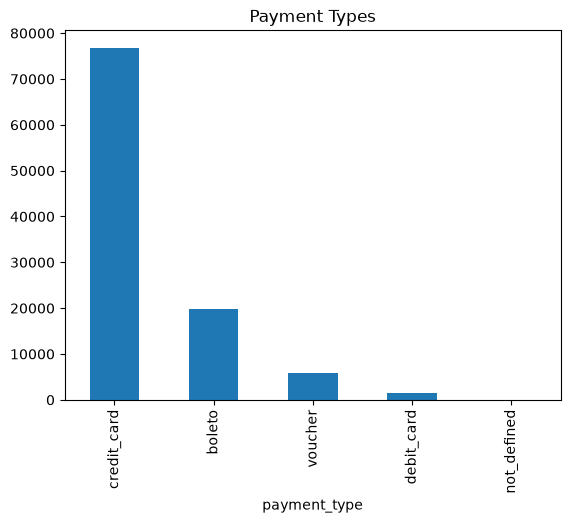

In [5]:
df['payment_type'].value_counts().plot(kind='bar', title='Payment Types')

<Axes: title={'center': 'Payment Installments Distribution'}, xlabel='payment_installments'>

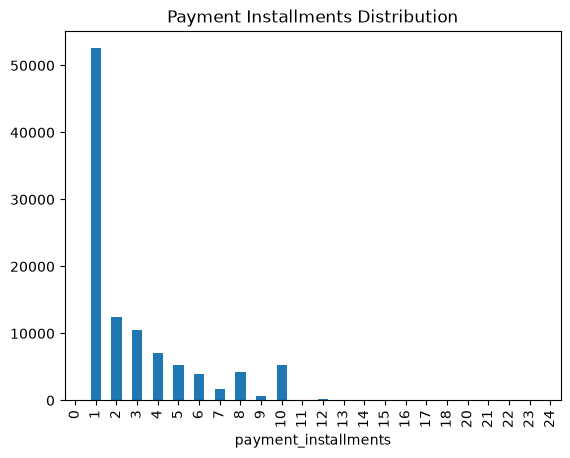

In [6]:
df['payment_installments'].value_counts().sort_index().plot(kind='bar', title='Payment Installments Distribution')

In [7]:
print('Sequential payments > 1 count:', (df['payment_sequential'] > 1).sum())

Sequential payments > 1 count: 4526


### Takeaways
- Credit card is by far the most popular payment method, followed by boleto.
- Single installments are the most common, but many users stretch payments over up to 10 months.
- Over 4,500 rows represent sequential (split) payments, meaning `order_id` is not unique in this table.